In [25]:
!pip install nltk
!pip install wordcloud

import nltk

nltk.download('punkt')

nltk.download('punkt_tab')

nltk.download('stopwords')

nltk.download('wordnet')

nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\sumit\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\sumit\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sumit\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\sumit\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\sumit\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [26]:
import pandas as pd
import numpy as np

from nltk.tokenize import word_tokenize

from nltk.corpus import stopwords

from nltk.stem import WordNetLemmatizer

from nltk import pos_tag

from wordcloud import WordCloud

import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer

from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import classification_report

In [ ]:
df["token_stmt"] = df["statement"].astype(str).apply(

    word_tokenize
)

In [28]:
df = pd.read_csv(
    r"C:\Users\sumit\Downloads\Combined Data.csv"
)

# Display dataset
print(df.head())

   Unnamed: 0                                          statement   status
0           0                                         oh my gosh  Anxiety
1           1  trouble sleeping, confused mind, restless hear...  Anxiety
2           2  All wrong, back off dear, forward doubt. Stay ...  Anxiety
3           3  I've shifted my focus to something else but I'...  Anxiety
4           4  I'm restless and restless, it's been a month n...  Anxiety


In [29]:
print("\nColumns:\n")

print(df.columns)


Columns:

Index(['Unnamed: 0', 'statement', 'status'], dtype='object')


In [35]:
from nltk.tokenize import word_tokenize

df["token_stmt"] = df["statement"].astype(str).apply(

    word_tokenize
)

print(df["token_stmt"].head())

0                                       [oh, my, gosh]
1    [trouble, sleeping, ,, confused, mind, ,, rest...
2    [All, wrong, ,, back, off, dear, ,, forward, d...
3    [I, 've, shifted, my, focus, to, something, el...
4    [I, 'm, restless, and, restless, ,, it, 's, be...
Name: token_stmt, dtype: object


In [36]:
df["token_lower"] = df["token_stmt"].apply(

    lambda tokens:

    [word.lower() for word in tokens]
)

print(df["token_lower"].head())

0                                       [oh, my, gosh]
1    [trouble, sleeping, ,, confused, mind, ,, rest...
2    [all, wrong, ,, back, off, dear, ,, forward, d...
3    [i, 've, shifted, my, focus, to, something, el...
4    [i, 'm, restless, and, restless, ,, it, 's, be...
Name: token_lower, dtype: object


In [37]:
stop_words = set(stopwords.words('english'))

df["token_stop"] = df["token_lower"].apply(

    lambda tokens:

    [

        word for word in tokens

        if word.isalpha()

        and word not in stop_words
    ]
)
print("\nStopwords Removed:\n")

print(df["token_stop"].head())


Stopwords Removed:

0                                           [oh, gosh]
1    [trouble, sleeping, confused, mind, restless, ...
2    [wrong, back, dear, forward, doubt, stay, rest...
3    [shifted, focus, something, else, still, worried]
4               [restless, restless, month, boy, mean]
Name: token_stop, dtype: object


In [38]:
lemmatizer = WordNetLemmatizer()

df["token_lemma"] = df["token_stop"].apply(

    lambda tokens:

    [

        lemmatizer.lemmatize(word)

        for word in tokens
    ]
)

print("\nLemmatized Text:\n")

print(df["token_lemma"].head())


Lemmatized Text:

0                                           [oh, gosh]
1    [trouble, sleeping, confused, mind, restless, ...
2    [wrong, back, dear, forward, doubt, stay, rest...
3    [shifted, focus, something, else, still, worried]
4               [restless, restless, month, boy, mean]
Name: token_lemma, dtype: object


In [ ]:
nltk.download('averaged_perceptron_tagger_eng')
df["pos_tag"] = df["token_lemma"].apply(

    pos_tag
)

print("\nPOS Tags:\n")

print(df["pos_tag"].head())

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\sumit\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping taggers\averaged_perceptron_tagger_eng.zip.


In [44]:
adjectives = []

for row in df["pos_tag"]:

    for word, tag in row:

        if tag in ['JJ', 'JJR', 'JJS']:

            adjectives.append(word)

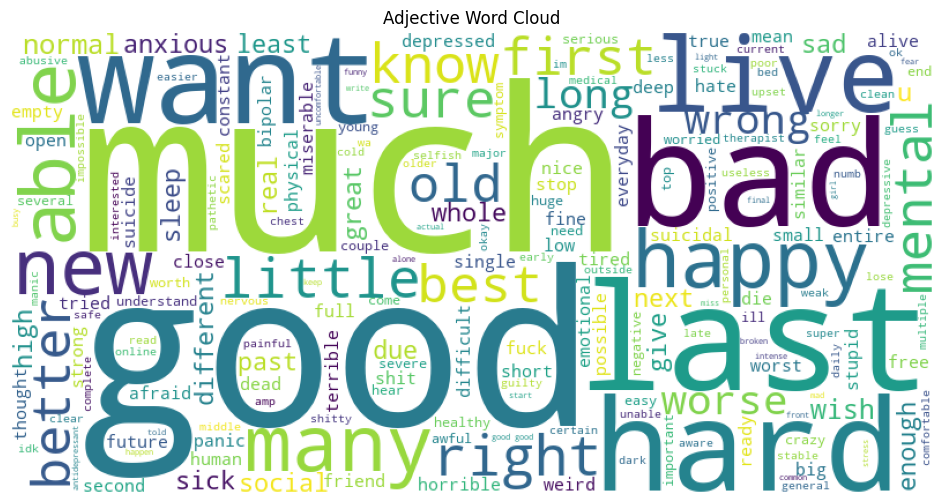

In [47]:
text = " ".join(adjectives)

wordcloud = WordCloud(

    width=800,

    height=400,

    background_color='white'
).generate(text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Adjective Word Cloud")

plt.show()

In [54]:
df["final_text"] = df["token_lemma"].apply(

    lambda tokens:

    " ".join(tokens)
)

In [55]:
vectorizer = CountVectorizer()

X = vectorizer.fit_transform(

    df["final_text"]
)

In [59]:
y = df["status"]

In [60]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42
)

In [61]:
model = MultinomialNB()

model.fit(

    X_train,

    y_train
)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [62]:
y_pred = model.predict(X_test)

In [63]:
print("\nClassification Report:\n")

print(

    classification_report(

        y_test,

        y_pred
    )
)


Classification Report:

                      precision    recall  f1-score   support

             Anxiety       0.68      0.72      0.70       779
             Bipolar       0.70      0.57      0.63       580
          Depression       0.49      0.70      0.58      3100
              Normal       0.93      0.66      0.77      3327
Personality disorder       0.62      0.14      0.23       248
              Stress       0.47      0.21      0.29       557
            Suicidal       0.59      0.65      0.62      2018

            accuracy                           0.63     10609
           macro avg       0.64      0.52      0.54     10609
        weighted avg       0.67      0.63      0.63     10609

